Random Forest AUC: 0.69
Logistic Regression AUC: 0.674

Top Features:
                   feature  rf_importance  log_coef
3   Prior Inpatient Visits       0.129984  0.303734
42      Discharge Type (1)       0.036088 -0.118234
6    Number of Medications       0.034322  0.046269
44     Discharge Type (11)       0.033561 -4.157473
4           Lab Procedures       0.030812 -0.002333
0           Length of Stay       0.030540 -0.022460
2         Emergency Visits       0.028777  0.035055
55     Discharge Type (22)       0.024649  1.123990
7      Number of Diagnoses       0.024588  0.027612
1        number_outpatient       0.014467 -0.007051


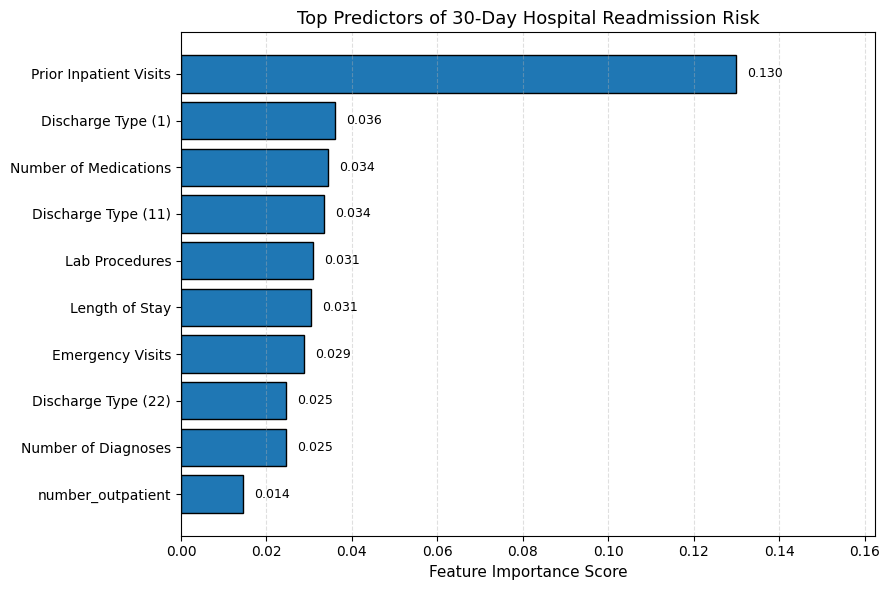

In [ ]:
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Load data
con = duckdb.connect("hospital_readmission.duckdb")

con.execute("DROP TABLE IF EXISTS patients")
con.execute("DROP TABLE IF EXISTS encounters")
con.execute("DROP TABLE IF EXISTS clinical")
con.execute("DROP TABLE IF EXISTS medications_outcomes")

con.execute("CREATE TABLE patients AS SELECT * FROM read_parquet('patients.parquet')")
con.execute("CREATE TABLE encounters AS SELECT * FROM read_parquet('encounters.parquet')")
con.execute("CREATE TABLE clinical AS SELECT * FROM read_parquet('clinical.parquet')")
con.execute("CREATE TABLE medications_outcomes AS SELECT * FROM read_parquet('medications_outcomes.parquet')")

# Join tables
model_df = con.sql("""
SELECT
    e.encounter_id,
    e.patient_nbr,
    p.race,
    p.gender,
    p.age,
    p.weight,
    e.admission_type_id,
    e.discharge_disposition_id,
    e.admission_source_id,
    e.time_in_hospital,
    e.payer_code,
    e.medical_specialty,
    e.number_outpatient,
    e.number_emergency,
    e.number_inpatient,
    c.num_lab_procedures,
    c.num_procedures,
    c.num_medications,
    c.number_diagnoses,
    c.diag_1,
    c.diag_2,
    c.diag_3,
    c.max_glu_serum,
    c.A1Cresult,
    m.metformin,
    m.insulin,
    m.change,
    m.diabetesMed,
    m.readmitted
FROM encounters e
JOIN patients p USING (patient_nbr)
JOIN clinical c USING (encounter_id)
JOIN medications_outcomes m USING (encounter_id)
""").df()

# Clean data
for col in model_df.columns:
    if model_df[col].dtype == object:
        model_df[col] = model_df[col].replace({
            "?": np.nan,
            "NULL": np.nan,
            "Not Available": np.nan,
            "Not Mapped": np.nan,
            "Unknown/Invalid": np.nan
        })

# Treat ID columns as categorical
model_df["admission_type_id"] = model_df["admission_type_id"].astype(str)
model_df["discharge_disposition_id"] = model_df["discharge_disposition_id"].astype(str)
model_df["admission_source_id"] = model_df["admission_source_id"].astype(str)

# Target
model_df["readmit_30d"] = (model_df["readmitted"] == "<30").astype(int)

# Features
X = model_df.drop(columns=["readmitted", "readmit_30d", "encounter_id", "patient_nbr"])
y = model_df["readmit_30d"]

categorical_cols = X.select_dtypes(include="object").columns.tolist()
numeric_cols = [col for col in X.columns if col not in categorical_cols]

# Preprocessing
preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_cols)
])

# Models
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        min_samples_leaf=10,
        class_weight="balanced_subsample",
        random_state=42
    ))
])

log_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=3000))
])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


# Train models
rf_model.fit(X_train, y_train)
log_model.fit(X_train, y_train)

# Evaluate
rf_auc = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1])
log_auc = roc_auc_score(y_test, log_model.predict_proba(X_test)[:, 1])

print("Random Forest AUC:", round(rf_auc, 3))
print("Logistic Regression AUC:", round(log_auc, 3))

# Compare feature importance / coefficients
feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()
rf_importance = rf_model.named_steps["model"].feature_importances_
log_coef = log_model.named_steps["model"].coef_[0]

results_df = pd.DataFrame({
    "feature": feature_names,
    "rf_importance": rf_importance,
    "log_coef": log_coef
})

results_df["feature"] = (
    results_df["feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

rename_dict = {
    "number_inpatient": "Prior Inpatient Visits",
    "num_medications": "Number of Medications",
    "num_lab_procedures": "Lab Procedures",
    "num_procedures": "Number of Procedures",
    "time_in_hospital": "Length of Stay",
    "number_emergency": "Emergency Visits",
    "number_diagnoses": "Number of Diagnoses"
}

results_df["feature"] = results_df["feature"].replace(rename_dict)

results_df["feature"] = results_df["feature"].str.replace(
    r"discharge_disposition_id_(\d+)",
    r"Discharge Type (\1)",
    regex=True
)

top_results = results_df.sort_values("rf_importance", ascending=False).head(10)

print("\nTop Features:")
print(top_results)

# Feature importance plot
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_importance
})

importance_df["feature"] = (
    importance_df["feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

rename_dict = {
    "number_inpatient": "Prior Inpatient Visits",
    "num_medications": "Number of Medications",
    "num_lab_procedures": "Lab Procedures",
    "num_procedures": "Number of Procedures",
    "time_in_hospital": "Length of Stay",
    "number_emergency": "Emergency Visits",
    "number_diagnoses": "Number of Diagnoses"
}

importance_df["feature"] = importance_df["feature"].replace(rename_dict)

importance_df["feature"] = importance_df["feature"].str.replace(
    r"discharge_disposition_id_(\d+)",
    r"Discharge Type (\1)",
    regex=True
)

top_features = importance_df.sort_values("importance", ascending=False).head(10)

fig, ax = plt.subplots(figsize=(9,6))

ax.barh(
    top_features["feature"],
    top_features["importance"],
    edgecolor='black'
)

ax.set_xlabel("Feature Importance Score", fontsize=11)
ax.set_title("Top Predictors of 30-Day Hospital Readmission Risk", fontsize=13)

ax.invert_yaxis()

max_val = top_features["importance"].max()
ax.set_xlim(0, max_val * 1.25)

for i, v in enumerate(top_features["importance"]):
    ax.text(v + max_val*0.02, i, f"{v:.3f}", va='center', fontsize=9)

ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

A Random Forest model was used as the primary predictive model because it can capture complex nonlinear relationships and interactions between patient characteristics, clinical variables, and hospital utilization patterns. This is important in healthcare data, since relationships between variables are often not strictly linear. I also used a logistic regression model to improve interpretability by providing coefficients that indicate how individual features are associated with readmission risk. To ensure stable and reliable coefficient estimates, numeric variables were standardized before fitting the logistic regression model. Both models were trained using a train-test split to evaluate performance. The Random Forest achieved a slightly higher AUC, indicating stronger predictive performance, while the logistic regression model provided clearer insight into the direction and magnitude of feature effects. Using both models allows for a balance between predictive accuracy and interpretability, which is crucial when analyzing healthcare outcomes such as hospital readmissions.

The feature importance visualization was designed to clearly communicate which variables are most influential in predicting 30-day hospital readmission risk. A horizontal bar chart was chosen because it allows for easy comparison of the top predictors while maintaining readability of feature names. The plot focuses on the top 10 most important features to reduce clutter and highlight the most meaningful variables. Feature names were cleaned and simplified to improve interpretability for a non-technical audience, and discharge disposition codes were reformatted into more readable labels. Value labels were added to provide precise importance scores, and the axis range was adjusted to ensure readability and prevent overlap with plot elements. The chart uses a clean layout with minimal visual distractions and a light grid to guide interpretation, making it suitable for a professional or publication-quality setting. This visualization directly supports the model results by showing which factors contribute most to readmission risk.